<a href="https://colab.research.google.com/github/MiguelAngeloTr/Aprendizaje_Automatico/blob/main/SEMANA_2_3/DATASET_PULSARS/DATASET_PULSARS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANÁLISIS EXPLORATORIO DE DATOS (EDA) - DATASET PULSARS

In [10]:

# ------------------------------------------------------------
# 1. Importación de librerías
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid', palette='deep', font_scale=1.1)

# ------------------------------------------------------------
# 2. Carga del dataset
# ------------------------------------------------------------
url = "https://raw.githubusercontent.com/MiguelAngeloTr/Aprendizaje_Automatico/refs/heads/main/SEMANA_2_3/DATASET_PULSARS/data_pulsars.csv"
pulsars = pd.read_csv(url)

print("Dataset cargado correctamente.")
print(f"Filas: {pulsars.shape[0]}  |  Columnas: {pulsars.shape[1]}")
pulsars.head()


Dataset cargado correctamente.
Filas: 17898  |  Columnas: 9


,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0



Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                17898 non-null  float64
 1    Standard deviation of the integrated profile  17898 non-null  float64
 2    Excess kurtosis of the integrated profile     17898 non-null  float64
 3    Skewness of the integrated profile            17898 non-null  float64
 4    Mean of the DM-SNR curve                      17898 non-null  float64
 5    Standard deviation of the DM-SNR curve        17898 non-null  float64
 6    Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7    Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                   17898 non-null  int64  
dtypes: float64(8), 

,count,mean,std,min,25%,50%,75%,max
Mean of the integrated profile,17898.0,111.079968,25.652935,5.812500,100.929688,115.078125,127.085938,192.617188
Standard deviation of the integrated profile,17898.0,46.549532,6.843189,24.772042,42.376018,46.947479,51.023202,98.778911
Excess kurtosis of the integrated profile,17898.0,0.477857,1.064040,-1.876011,0.027098,0.223240,0.473325,8.069522
Skewness of the integrated profile,17898.0,1.770279,6.167913,-1.791886,-0.188572,0.198710,0.927783,68.101622
Mean of the DM-SNR curve,17898.0,12.614400,29.472897,0.213211,1.923077,2.801839,5.464256,223.392141
Standard deviation of the DM-SNR curve,17898.0,26.326515,19.470572,7.370432,14.437332,18.461316,28.428104,110.642211
Excess kurtosis of the DM-SNR curve,17898.0,8.303556,4.506092,-3.139270,5.781506,8.433515,10.702959,34.539844
Skewness of the DM-SNR curve,17898.0,104.857709,106.514540,-1.976976,34.960504,83.064556,139.309330,1191.000837
target_class,17898.0,0.091574,0.288432,0.000000,0.000000,0.000000,0.000000,1.000000



Valores nulos por columna:
 Mean of the integrated profile                  0
 Standard deviation of the integrated profile    0
 Excess kurtosis of the integrated profile       0
 Skewness of the integrated profile              0
 Mean of the DM-SNR curve                        0
 Standard deviation of the DM-SNR curve          0
 Excess kurtosis of the DM-SNR curve             0
 Skewness of the DM-SNR curve                    0
target_class                                     0
dtype: int64

Registros duplicados:
0


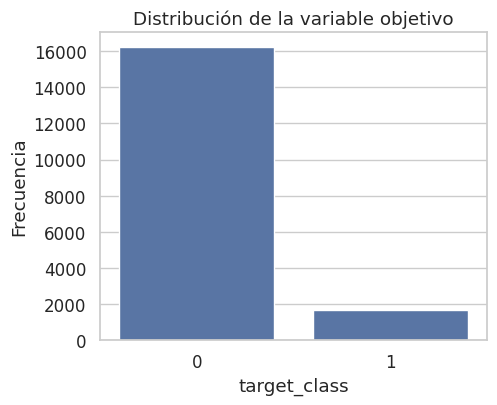

In [11]:

# ------------------------------------------------------------
# 3. Información general del dataset
# ------------------------------------------------------------
print("\nInformación general del DataFrame:")
pulsars.info()

print("\nResumen estadístico de las variables numéricas:")
display(pulsars.describe().T)

# ------------------------------------------------------------
# 4. Revisión de valores nulos y duplicados
# ------------------------------------------------------------
print("\nValores nulos por columna:")
print(pulsars.isnull().sum())

print("\nRegistros duplicados:")
print(pulsars.duplicated().sum())

# ------------------------------------------------------------
# 5. Distribución de la variable objetivo
# ------------------------------------------------------------
# Se asume que la última columna corresponde a la variable objetivo
target_col = 'target_class' if 'target_class' in pulsars.columns else pulsars.columns[-1]

plt.figure(figsize=(5,4))
sns.countplot(data=pulsars, x=target_col)
plt.title('Distribución de la variable objetivo')
plt.xlabel(target_col)
plt.ylabel('Frecuencia')
plt.show()


In [9]:
# ------------------------------------------------------------
# Reducción de la clase mayoritaria (undersampling)
# ------------------------------------------------------------
from sklearn.utils import resample

# Separar las clases
mayoritaria = pulsars[pulsars[target_col] == 0]
minoritaria = pulsars[pulsars[target_col] == 1]

# Definir tamaño de la clase minoritaria
tamano_min = len(minoritaria)

# Submuestrear la clase mayoritaria
mayoritaria_reducida = resample(mayoritaria,
                                replace=False,      # sin reemplazo
                                n_samples=tamano_min,  # igualar tamaño
                                random_state=42)

# Combinar ambas clases
pulsars_balanceado = pd.concat([mayoritaria_reducida, minoritaria])

# Mezclar filas aleatoriamente
pulsars_balanceado = pulsars_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribución original:")
print(pulsars[target_col].value_counts())
print("\nDistribución tras submuestreo:")
print(pulsars_balanceado[target_col].value_counts())


Distribución original:
target_class
0    16259
1     1639
Name: count, dtype: int64

Distribución tras submuestreo:
target_class
1    1639
0    1639
Name: count, dtype: int64


/tmp/ipython-input-4007975207.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pulsars_balanceado, x=target_col, palette="Set2")


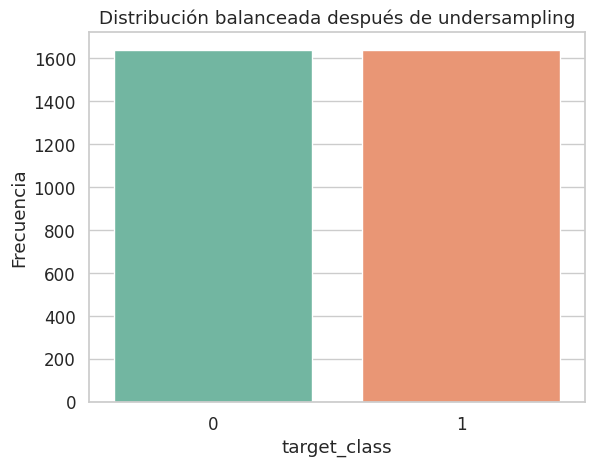

In [13]:

sns.countplot(data=pulsars_balanceado, x=target_col, palette="Set2")
plt.title("Distribución balanceada después de undersampling")
plt.xlabel(target_col)
plt.ylabel("Frecuencia")
plt.show()


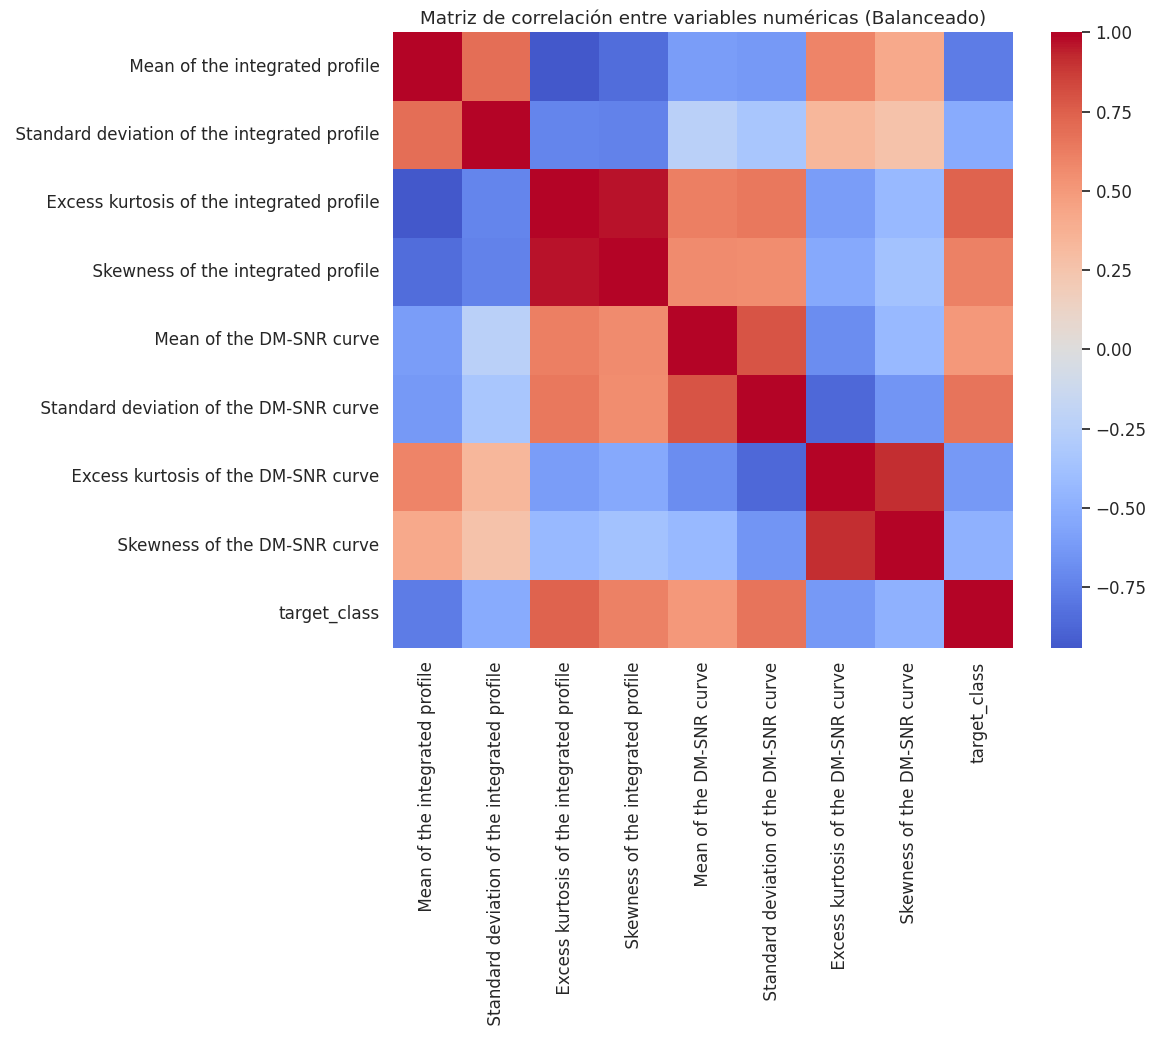

In [16]:
# ------------------------------------------------------------
# 6. Matriz de correlación
# ------------------------------------------------------------
plt.figure(figsize=(10,8))
corr = pulsars_balanceado.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables numéricas (Balanceado)')
plt.show()



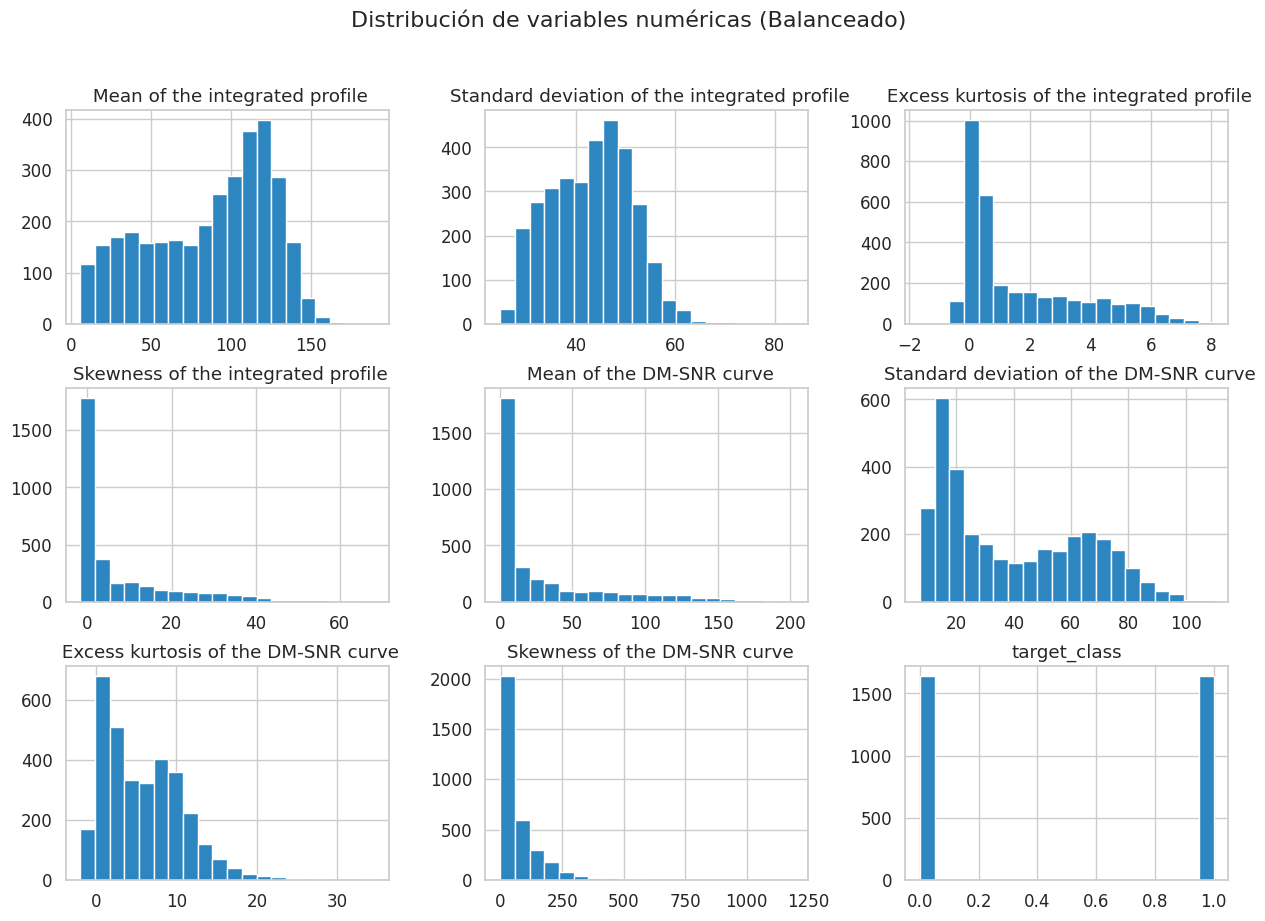

In [18]:

# ------------------------------------------------------------
# 7. Distribución de variables numéricas
# ------------------------------------------------------------
num_cols = pulsars_balanceado.select_dtypes(include=np.number).columns

pulsars_balanceado[num_cols].hist(bins=20, figsize=(15,10), color='#2E86C1')
plt.suptitle('Distribución de variables numéricas (Balanceado)', fontsize=16)
plt.show()


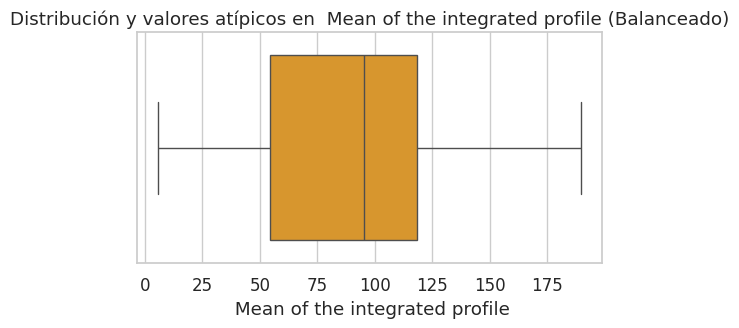

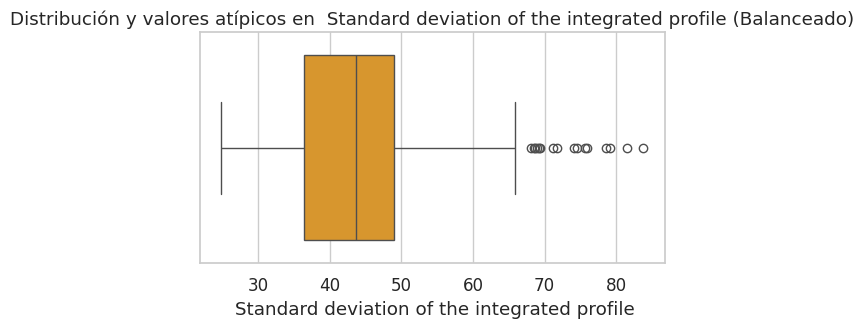

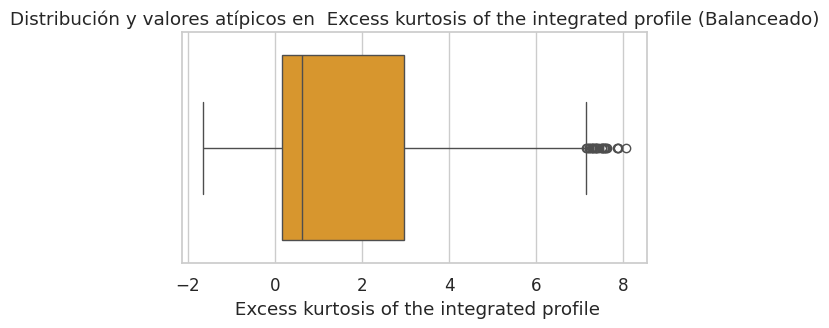

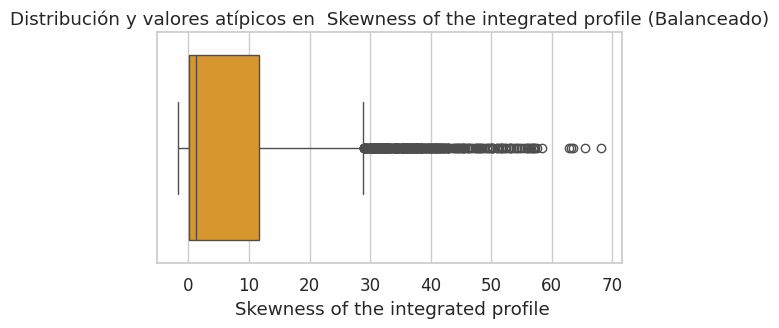

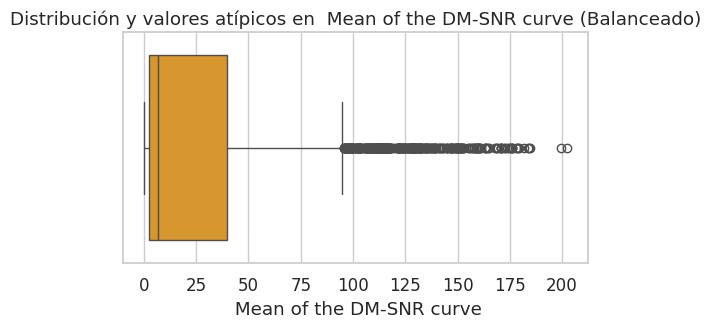

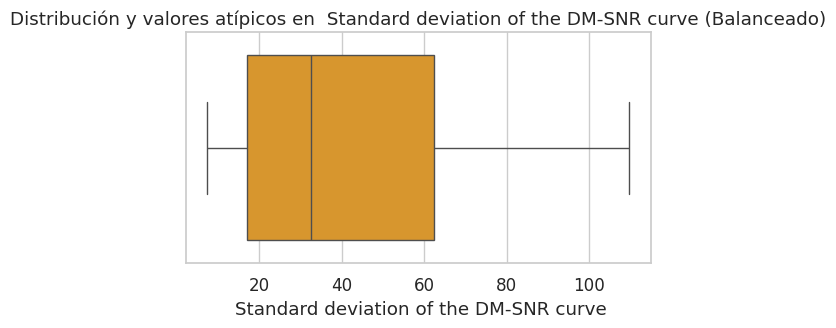

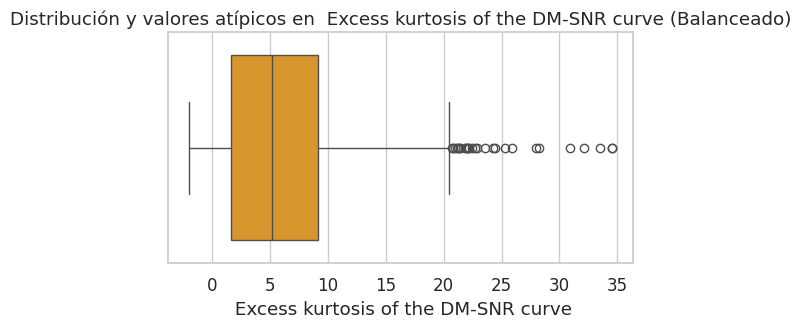

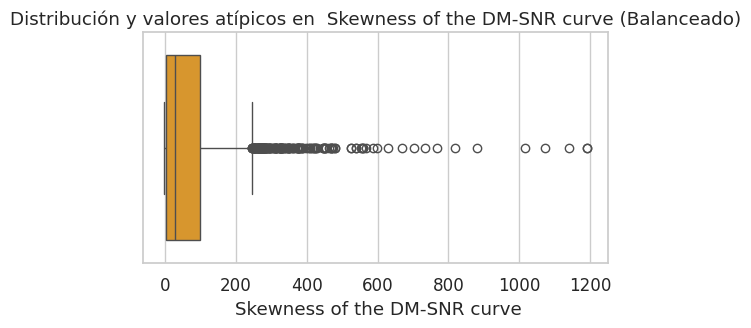

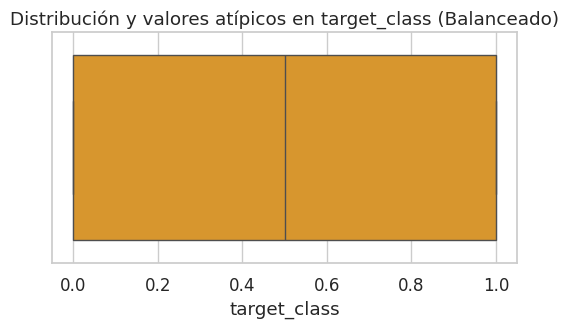

/tmp/ipython-input-5230912.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pulsars_balanceado, x=target_col, y=col, palette='Set2')


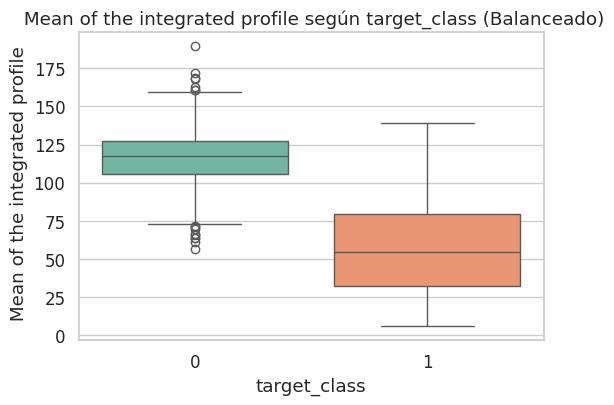

/tmp/ipython-input-5230912.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pulsars_balanceado, x=target_col, y=col, palette='Set2')


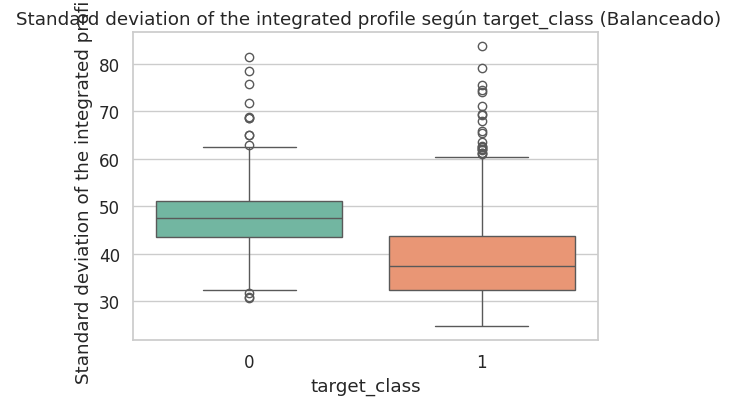

/tmp/ipython-input-5230912.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pulsars_balanceado, x=target_col, y=col, palette='Set2')


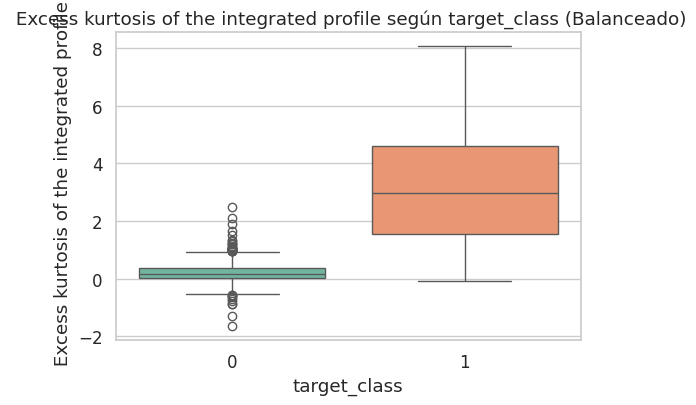

/tmp/ipython-input-5230912.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pulsars_balanceado, x=target_col, y=col, palette='Set2')


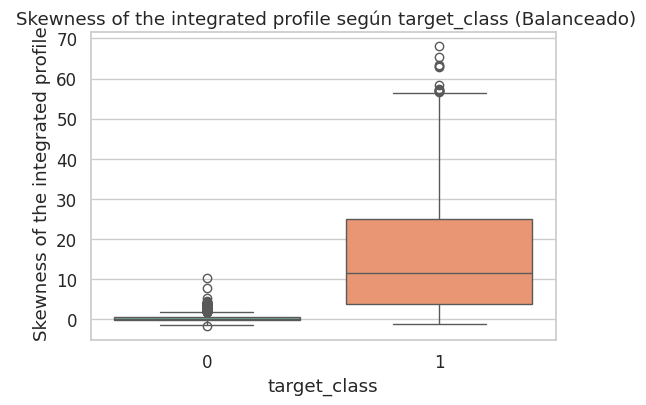

/tmp/ipython-input-5230912.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pulsars_balanceado, x=target_col, y=col, palette='Set2')


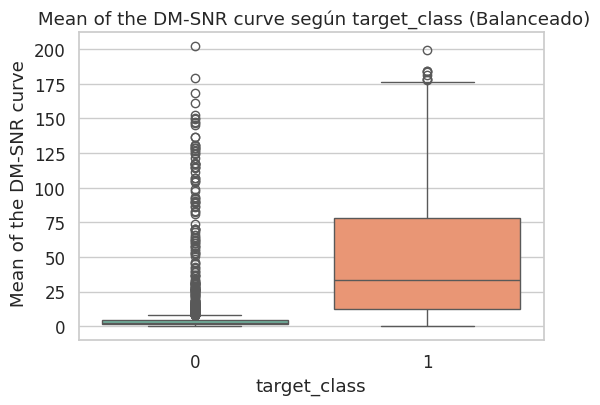

/tmp/ipython-input-5230912.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pulsars_balanceado, x=target_col, y=col, palette='Set2')


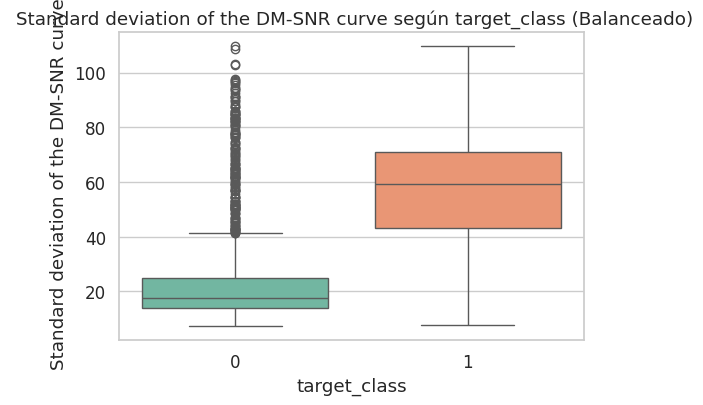

/tmp/ipython-input-5230912.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pulsars_balanceado, x=target_col, y=col, palette='Set2')


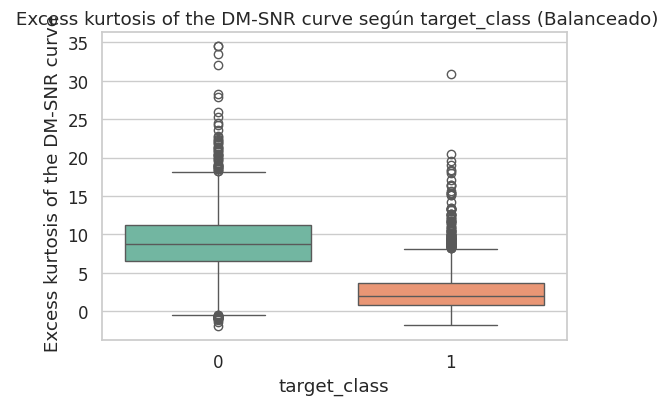

/tmp/ipython-input-5230912.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pulsars_balanceado, x=target_col, y=col, palette='Set2')


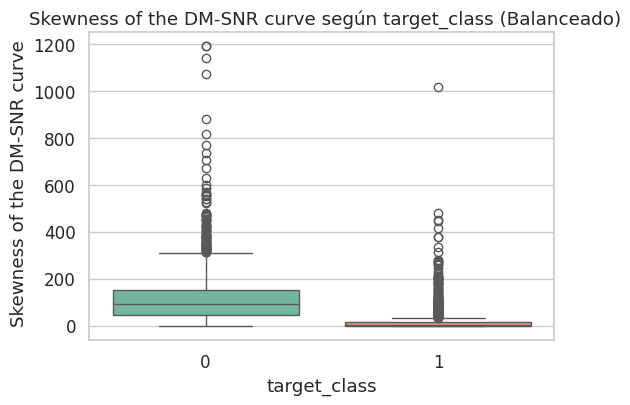


Variables más correlacionadas con la variable objetivo (Balanceado):
Mean of the integrated profile                 -0.775803
Excess kurtosis of the integrated profile       0.736904
Standard deviation of the DM-SNR curve          0.665817
Excess kurtosis of the DM-SNR curve            -0.629212
Skewness of the integrated profile              0.608347
Standard deviation of the integrated profile   -0.521354
Mean of the DM-SNR curve                        0.501010
Skewness of the DM-SNR curve                   -0.482997
Name: target_class, dtype: float64


In [17]:
# ------------------------------------------------------------
# 8. Boxplots para detección de valores atípicos
# ------------------------------------------------------------
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=pulsars_balanceado[col], color='#F39C12')
    plt.title(f'Distribución y valores atípicos en {col} (Balanceado)')
    plt.show()

# ------------------------------------------------------------
# 9. Relación entre variables principales y variable objetivo
# ------------------------------------------------------------
if target_col in pulsars_balanceado.columns:
    for col in num_cols:
        if col != target_col:
            plt.figure(figsize=(6,4))
            sns.boxplot(data=pulsars_balanceado, x=target_col, y=col, palette='Set2')
            plt.title(f'{col} según {target_col} (Balanceado)')
            plt.show()

# ------------------------------------------------------------
# 10. Correlaciones más fuertes con la variable objetivo
# ------------------------------------------------------------
if target_col in pulsars_balanceado.columns:
    correlations = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)
    print("\nVariables más correlacionadas con la variable objetivo (Balanceado):")
    print(correlations.head(10))


In [19]:
# ============================================================
# PERCEPTRON SIMPLE APLICADO AL DATASET DE PÚLSARES
# ============================================================

# ------------------------------------------------------------
# 1. Selección de dos características y creación de X, y
# ------------------------------------------------------------
# Escogemos dos variables numéricas representativas
caracteristicas = [' Mean of the integrated profile', ' Standard deviation of the integrated profile']
X = pulsars_balanceado[caracteristicas].values
y = pulsars_balanceado[target_col].values

print("Características seleccionadas:", caracteristicas)
print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)



Características seleccionadas: [' Mean of the integrated profile', ' Standard deviation of the integrated profile']
Tamaño de X: (3278, 2)
Tamaño de y: (3278,)


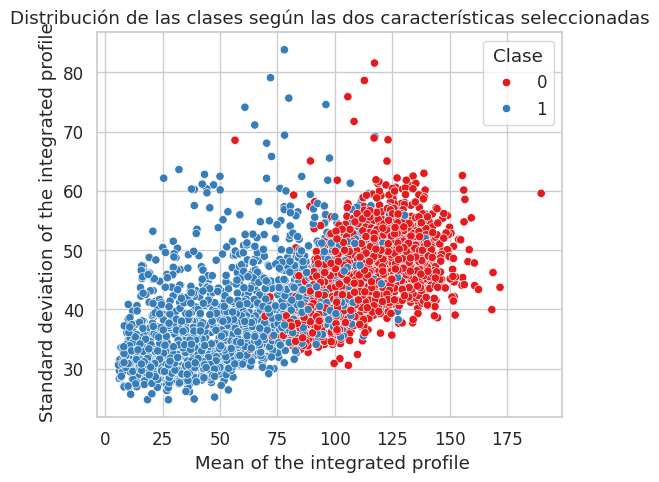

In [20]:
# ------------------------------------------------------------
# 2. Gráfico de dispersión de las dos características
# ------------------------------------------------------------
plt.figure(figsize=(6,5))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='Set1')
plt.title('Distribución de las clases según las dos características seleccionadas')
plt.xlabel(caracteristicas[0])
plt.ylabel(caracteristicas[1])
plt.legend(title='Clase')
plt.show()




In [21]:
# ------------------------------------------------------------
# 3. Implementación y entrenamiento del Perceptron
# ------------------------------------------------------------
from sklearn.linear_model import Perceptron

# Configuración del modelo
perceptron = Perceptron(max_iter=50, eta0=0.01, random_state=42)

# Entrenamiento manual para registrar la evolución del error y pesos
w1_hist, w2_hist, b_hist, errores = [], [], [], []

# Inicializar pesos y sesgo
perceptron.partial_fit(X, y, classes=np.unique(y))
w = perceptron.coef_[0]
b = perceptron.intercept_[0]

for epoch in range(50):
    perceptron.partial_fit(X, y)
    y_pred = perceptron.predict(X)
    error = np.mean(y_pred != y)

    errores.append(error)
    w1_hist.append(perceptron.coef_[0][0])
    w2_hist.append(perceptron.coef_[0][1])
    b_hist.append(perceptron.intercept_[0])



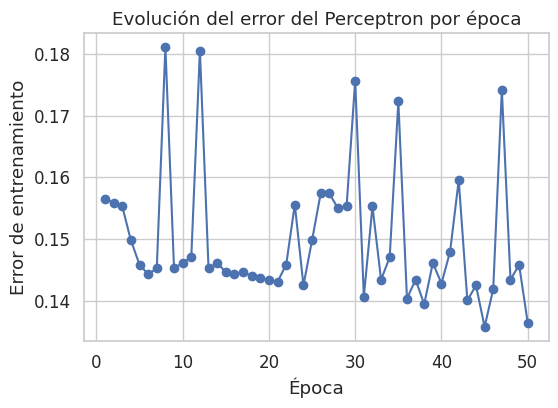

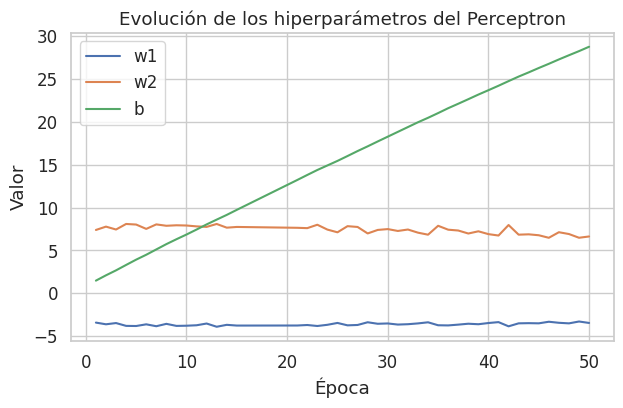

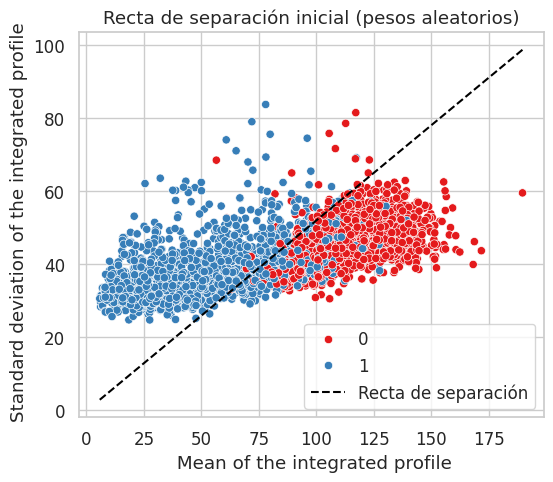

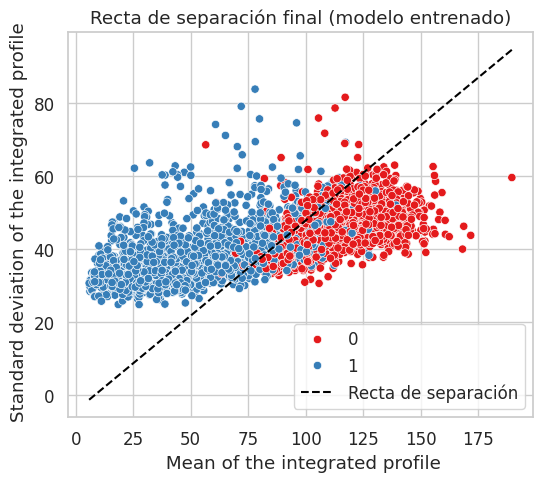

In [22]:
# ------------------------------------------------------------
# 4.1. Variabilidad del error por épocas
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(range(1, 51), errores, marker='o')
plt.title('Evolución del error del Perceptron por época')
plt.xlabel('Época')
plt.ylabel('Error de entrenamiento')
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 4.2. Variabilidad de los hiperparámetros (w1, w2, b)
# ------------------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(range(1,51), w1_hist, label='w1')
plt.plot(range(1,51), w2_hist, label='w2')
plt.plot(range(1,51), b_hist, label='b')
plt.title('Evolución de los hiperparámetros del Perceptron')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 4.3. Recta de separación inicial
# ------------------------------------------------------------
def plot_decision_boundary(w, b, X, y, title):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='Set1')
    x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    y_vals = -(w[0]/w[1]) * x_vals - b/w[1]
    plt.plot(x_vals, y_vals, color='black', linestyle='--', label='Recta de separación')
    plt.title(title)
    plt.xlabel(caracteristicas[0])
    plt.ylabel(caracteristicas[1])
    plt.legend()
    plt.show()

# Obtener pesos iniciales antes del entrenamiento
w_ini = [w[0], w[1]]
b_ini = b
plot_decision_boundary(w_ini, b_ini, X, y, "Recta de separación inicial (pesos aleatorios)")

# ------------------------------------------------------------
# 4.4. Recta de separación final (modelo entrenado)
# ------------------------------------------------------------
w_final = perceptron.coef_[0]
b_final = perceptron.intercept_[0]
plot_decision_boundary(w_final, b_final, X, y, "Recta de separación final (modelo entrenado)")